# Model Comparison

This notebook compares the competition model with a (asymmetric) feedback model.

## Note: the two models use *different* degron rates - this is deliberate

**The measured degradation rates are shared and identical in both models:**

- $\delta_n^A$ - nuclear removal of mCherry-POLR2A (bleach chase, vehicle and
  5-Ph-IAA pooled; the removal rate is unaffected by 5-Ph-IAA)
- $\delta_n^B = f_B \cdot \delta_n^A$ - basal nuclear removal of mAC-POLR2A

**What differs is the auxin (degron) increment $\delta_n^B(\mathrm{degron})$**, which is fitted
separately inside each model (`DELTA_N_B_DEGRON_COMP` vs `DELTA_N_B_DEGRON_FB`). This is
expected, because the two models deliver protein B to the nucleus in different ways:

- **Competition model:** the degron acts on B wherever it is, so it is added to the
  cytoplasmic rate $\delta_f^B$ as well as to $\delta_n^B$. Depleting the free cytoplasmic
  pool collapses the nuclear import flux, so nuclear mClover falls both from direct nuclear
  degradation *and* from loss of supply. A **smaller** increment reproduces the observed decay.
- **Feedback model:** there is no cytoplasmic compartment, so the degron can only raise the
  nuclear removal rate. Synthesis feeds the nucleus directly and is compensatory (it rises as
  total protein falls below $\text{Total}_{\text{ref}}$), so it *opposes* the decline. A
  **larger** increment is required to match the same decay.

The perturbation strength is therefore mechanism-dependent - it is not a model-independent
measurement, and the two values are not expected to agree.

**Related non-bug:** the two models sit at slightly different $t=0$ (control) levels because
each was fitted independently to the same data. Control $A_n$ scales as $1/\delta_n^A$ in both
models, so that fixed *relative* offset appears ~1.4x larger in *absolute* terms under ARMC5.


In [56]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from models import (
    competition_steady_state,
    simulate_competition_trajectory,
    integrate_feedback_to_steady_state,
    simulate_feedback_trajectory,
)
from utils import load_parameters

warnings.filterwarnings("ignore")

# Data directory (all input CSVs)
DATA_DIR = Path("../data")

# Plotting style
plt.rcParams.update(
    {"figure.figsize": (14, 6), "font.size": 11, "font.family": "Arial"}
)

## Load Fitted Parameters

In [57]:
# Load fitted parameters from both models.
# The competition model uses the SELECTED fit (K_M fixed at 1e-3, R_cyt = 0.2), which is the
# parameter set reported in the methods. See the note at the top of this notebook.
COMP_PARAMS_PATH = Path("fitted_parameters/competition_params_R0_2_manual_K_M.json")
comp_params = load_parameters(COMP_PARAMS_PATH)
fb_params = load_parameters("fitted_parameters/feedback_params.json")

print(f"Competition model parameters  ({COMP_PARAMS_PATH.name}):")
for key, val in comp_params.items():
    print(f"  {key}: {val:.6f}" if isinstance(val, float) else f"  {key}: {val}")

print("\nFeedback model parameters:")
for key, val in fb_params.items():
    print(f"  {key}: {val:.6f}" if isinstance(val, float) else f"  {key}: {val}")

Competition model parameters  (competition_params_R0_2_manual_K_M.json):
  k_s: 0.153341
  V_max: 0.164660
  k_import: 27.919766
  F_total: 0.005898
  K_M: 0.001000
  delta_f_A: 0.604979
  delta_n_B_degron: 2.043683
  delta_n_A: 0.135633
  delta_n_B_factor: 1.443294
  delta_n_B: 0.195758
  cyto_nuc_ratio: 0.200000
  f_total_floor_frac: 0.050000
  data_loss: 0.076867

Feedback model parameters:
  k_s_max: 1.000000
  S: 0.091648
  Total_ref: 1.014700
  delta_n_A: 0.135633
  delta_n_B_factor: 1.443294
  delta_n_B: 0.195758
  delta_n_B_degron: 2.309962


## Setup Simulation Conditions

In [58]:
# Simulation settings
PLOT_DURATION = 24.0  # total hours
NEGATIVE_LEAD = 2.0  # hours in timecourse before perturbation
N_POINTS = 200

# Normalization factors
RFP_NORM = 0.5994
GFP_NORM = 0.4153

# Measured degradation rates (shared by both models)
DELTA_N_A = comp_params["delta_n_A"]
DELTA_N_B_FACTOR = comp_params["delta_n_B_factor"]
DELTA_N_B = DELTA_N_B_FACTOR * DELTA_N_A

# Auxin (degron) increments: fit separately within each model - see note at top
DELTA_N_B_DEGRON_COMP = comp_params["delta_n_B_degron"]  # fit in notebook 1
DELTA_N_B_DEGRON_FB = fb_params["delta_n_B_degron"]  # fit in notebook 2

print(f"Simulation duration: {PLOT_DURATION} hours")
print(f"δ_n^A = {DELTA_N_A:.4f} hr⁻¹, δ_n^B = {DELTA_N_B:.4f} hr⁻¹ (both models)")
print(f"δ_n^B(degron), competition = {DELTA_N_B_DEGRON_COMP:.4f} hr⁻¹")
print(f"δ_n^B(degron), feedback    = {DELTA_N_B_DEGRON_FB:.4f} hr⁻¹")

Simulation duration: 24.0 hours
δ_n^A = 0.1356 hr⁻¹, δ_n^B = 0.1958 hr⁻¹ (both models)
δ_n^B(degron), competition = 2.0437 hr⁻¹
δ_n^B(degron), feedback    = 2.3100 hr⁻¹


## Generate Competition Model Trajectories

In [59]:
# Calculate degradation rates for competition model
delta_f_A = comp_params["delta_f_A"]
delta_f_B_control = delta_f_A
delta_f_B_perturbed = delta_f_A + DELTA_N_B_DEGRON_COMP
delta_n_B_control = DELTA_N_B
delta_n_B_perturbed = DELTA_N_B + DELTA_N_B_DEGRON_COMP

# Steady states, solved algebraically rather than by integrating to t = 200 h
# (see the validation cell in notebook 1)
comp_ss_control = competition_steady_state(
    comp_params, delta_f_B_control, DELTA_N_A, delta_n_B_control
)
comp_ss_perturbed = competition_steady_state(
    comp_params, delta_f_B_perturbed, DELTA_N_A, delta_n_B_perturbed
)

print("Competition model steady states:")
print(f"  Control:   A_n={comp_ss_control[2]:.3f}, B_n={comp_ss_control[3]:.3f}")
print(f"  Perturbed: A_n={comp_ss_perturbed[2]:.3f}, B_n={comp_ss_perturbed[3]:.3f}")
print(f"  Buffering of A_n: {comp_ss_perturbed[2] / comp_ss_control[2]:.3f}")

# Simulate trajectories
comp_trajectories = {}

# VEH_AUX: control → perturbed
traj, times = simulate_competition_trajectory(
    comp_params,
    delta_f_B_perturbed,
    DELTA_N_A,
    delta_n_B_perturbed,
    PLOT_DURATION,
    comp_ss_control,
    n_points=N_POINTS,
)
comp_trajectories["VEH_AUX"] = {"time": times, "A_n": traj[2], "B_n": traj[3]}

# AUX_VEH: perturbed → control
traj, times = simulate_competition_trajectory(
    comp_params,
    delta_f_B_control,
    DELTA_N_A,
    delta_n_B_control,
    PLOT_DURATION,
    comp_ss_perturbed,
    n_points=N_POINTS,
)
comp_trajectories["AUX_VEH"] = {"time": times, "A_n": traj[2], "B_n": traj[3]}

print("\nGenerated competition trajectories")

Competition model steady states:
  Control:   A_n=0.604, B_n=0.419
  Perturbed: A_n=0.800, B_n=0.024
  Buffering of A_n: 1.324

Generated competition trajectories


## Generate Feedback Model Trajectories

In [60]:
# Extract feedback parameters
k_s_max = fb_params["k_s_max"]
S = fb_params["S"]
Total_ref = fb_params["Total_ref"]
delta_A = fb_params["delta_n_A"]
delta_B_control = fb_params["delta_n_B"]
delta_B_perturbed = delta_B_control + DELTA_N_B_DEGRON_FB

# Calculate steady states
fb_ss_control = integrate_feedback_to_steady_state(
    k_s_max, S, Total_ref, delta_A, delta_B_control
)
fb_ss_perturbed = integrate_feedback_to_steady_state(
    k_s_max, S, Total_ref, delta_A, delta_B_perturbed
)

print("Feedback model steady states:")
print(f"  Control:   A={fb_ss_control[0]:.3f}, B={fb_ss_control[1]:.3f}")
print(f"  Perturbed: A={fb_ss_perturbed[0]:.3f}, B={fb_ss_perturbed[1]:.3f}")

# Simulate trajectories
fb_trajectories = {}

# VEH_AUX: control → perturbed
traj, times = simulate_feedback_trajectory(
    k_s_max,
    S,
    Total_ref,
    delta_A,
    delta_B_perturbed,
    PLOT_DURATION,
    fb_ss_control,
    n_points=N_POINTS,
)
fb_trajectories["VEH_AUX"] = {"time": times, "A_n": traj[0], "B_n": traj[1]}

# AUX_VEH: perturbed → control
traj, times = simulate_feedback_trajectory(
    k_s_max,
    S,
    Total_ref,
    delta_A,
    delta_B_control,
    PLOT_DURATION,
    fb_ss_perturbed,
    n_points=N_POINTS,
)
fb_trajectories["AUX_VEH"] = {"time": times, "A_n": traj[0], "B_n": traj[1]}

print("\nGenerated feedback trajectories")

Feedback model steady states:
  Control:   A=0.611, B=0.423
  Perturbed: A=0.758, B=0.041

Generated feedback trajectories


## Publication-Quality Compact Comparison

This section creates the key publication figure showing both models overlaid with experimental data.

In [61]:
# Load experimental data for overlay
from utils import load_experimental_data, calculate_time_averages

data_path = DATA_DIR / "mACmCh_LiveCellWashout_Values_ByExperiment.csv"
data = load_experimental_data(data_path, {"RFP": RFP_NORM, "GFP": GFP_NORM})

# Calculate time-averaged data
fit_conditions = ["VEH_AUX", "AUX_VEH"]
data_averaged = calculate_time_averages(data, fit_conditions)

# Use only first 12 hours
FIT_MAX_HOURS = 12.0
for code in fit_conditions:
    data_averaged[code] = data_averaged[code][
        data_averaged[code]["time"] <= FIT_MAX_HOURS
    ]

print(f"Loaded experimental data for: {list(data_averaged.keys())}")

Loaded experimental data for: ['VEH_AUX', 'AUX_VEH']


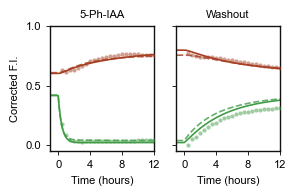

Saved publication figure to /Users/z3532965/src/publications/2026_POLR2A_homeostasis/Modelling/abundance_homeostasis/plots/model_comparison_publication.pdf


In [62]:
# Create publication-quality compact comparison figure

# Publication colors
color_gfp = "#419c46"
color_mcherry = "#a73f23"

# Create compact figure for publication
fig, axes = plt.subplots(1, 2, figsize=(3, 2), sharey=True)
fig.subplots_adjust(wspace=-1.5)
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 8

conditions_pub = [("VEH_AUX", "5-Ph-IAA"), ("AUX_VEH", "Washout")]

for idx, (ax, (code, title)) in enumerate(zip(axes, conditions_pub)):
    ax.set_facecolor("white")

    # Negative lead time
    neg_times = np.linspace(-NEGATIVE_LEAD, 0, 20)

    # Get competition trajectories
    comp_traj = comp_trajectories[code]
    A_n_comp_0 = comp_traj["A_n"][0]
    B_n_comp_0 = comp_traj["B_n"][0]
    A_neg_comp = np.full_like(neg_times, A_n_comp_0)
    B_neg_comp = np.full_like(neg_times, B_n_comp_0)
    time_comp = np.concatenate([neg_times, comp_traj["time"]])
    A_comp_full = np.concatenate([A_neg_comp, comp_traj["A_n"]])
    B_comp_full = np.concatenate([B_neg_comp, comp_traj["B_n"]])

    # Get feedback trajectories
    fb_traj = fb_trajectories[code]
    A_n_fb_0 = fb_traj["A_n"][0]
    B_n_fb_0 = fb_traj["B_n"][0]
    A_neg_fb = np.full_like(neg_times, A_n_fb_0)
    B_neg_fb = np.full_like(neg_times, B_n_fb_0)
    time_fb = np.concatenate([neg_times, fb_traj["time"]])
    A_fb_full = np.concatenate([A_neg_fb, fb_traj["A_n"]])
    B_fb_full = np.concatenate([B_neg_fb, fb_traj["B_n"]])

    # Plot feedback model (dashed)
    ax.plot(
        time_fb, B_fb_full, color=color_gfp, linewidth=1.2, linestyle="--", alpha=0.8
    )
    ax.plot(
        time_fb,
        A_fb_full,
        color=color_mcherry,
        linewidth=1.2,
        linestyle="--",
        alpha=0.8,
    )

    # Plot competition model (solid)
    ax.plot(time_comp, B_comp_full, color=color_gfp, linewidth=1.2, linestyle="-")
    ax.plot(time_comp, A_comp_full, color=color_mcherry, linewidth=1.2, linestyle="-")

    # Add experimental data points
    if code in data_averaged:
        exp_data = data_averaged[code]

        # Plot RFP data
        ax.scatter(
            exp_data["time"],
            exp_data["rfp"],
            marker="o",
            s=9,
            color=color_mcherry,
            linewidth=0,
            alpha=0.5,
            zorder=3,
        )

        # Plot GFP data
        ax.scatter(
            exp_data["time"],
            exp_data["gfp"],
            marker="o",
            s=9,
            color=color_gfp,
            linewidth=0,
            alpha=0.5,
            zorder=3,
        )

    # Formatting
    ax.set_xlim(-1, 12)
    ax.set_ylim(-0.05, 1.0)
    ax.set_xticks([0, 4, 8, 12])
    ax.set_yticks([0.0, 0.5, 1.0])
    ax.tick_params(
        axis="both", which="both", direction="out", length=3.0, width=0.6, labelsize=8
    )
    ax.set_title(title, fontsize=8)
    ax.set_xlabel("Time (hours)", fontsize=8)

    if idx == 0:
        ax.set_ylabel("Corrected F.I.", fontsize=8)
    else:
        ax.set_ylabel("")

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)
        spine.set_color("#111111")

axes[0].set_xticklabels(["0", "4", "8", "12"])
axes[1].set_xticklabels(["0", "4", "8", "12"])

fig.tight_layout()

# Save to publication path
output_pub_path = Path("plots/model_comparison_publication.pdf")
fig.savefig(output_pub_path, bbox_inches="tight")
plt.show()

print(f"Saved publication figure to {output_pub_path.resolve()}")

## ARMC5 Comparison: Normal vs ARMC5 Conditions

ARMC5 depletion is modelled as lengthening the **degradation** component of nuclear POLR2A
turnover, from a half-life of 6.9 h to 11.4 h, while retaining the measured dilution rate from
cell growth. All other parameters are held at their fitted values, including $F_\mathrm{total}$
and $k_\mathrm{import}$: the depletion acts on nuclear decay only.

In [63]:
# ARMC5 condition: longer protein half-life (11.4h vs 7h)
# Load bleach chase data to calculate ARMC5 degradation rate
bleach_chase_path_armc5 = DATA_DIR / "mACmCh_BleachChase_ByExperiment.csv"
bleach_chase_df_armc5 = pd.read_csv(bleach_chase_path_armc5, index_col=0)

# For ARMC5, use a fixed half-life of 11.4 hours (from prior experiments)
HALFLIFE_ARMC5 = 11.4

# Bleach-chase components, pooled across vehicle and 5-Ph-IAA (matching notebook 1:
# the removal rate is indistinguishable between treatments, so all n = 6 are used).
removal_rate = bleach_chase_df_armc5["RemovalRate_perhr"].mean()
degradation_rate = bleach_chase_df_armc5["DegradationRate_perhr"].mean()
dilution_rate = bleach_chase_df_armc5["GrowthRate_perhr"].mean()

# The measured rate here must match the one from the fitted parameters.
assert np.isclose(removal_rate, DELTA_N_A, rtol=1e-4), (
    f"Bleach-chase removal rate ({removal_rate:.4f}) does not match delta_n_A in the "
    f"parameter file ({DELTA_N_A:.4f}); re-run notebook 1."
)

# Switch the measured degradation out for the ARMC5 half-life; keep the measured dilution.
DELTA_N_A_ARMC5 = dilution_rate + np.log(2) / HALFLIFE_ARMC5
DELTA_N_B_FACTOR_ARMC5 = DELTA_N_B_FACTOR  # Same ratio as Normal

print("ARMC5 condition parameters:")
print(f"  Measured degradation half-life: {np.log(2) / degradation_rate:.1f} h")
print(f"  ARMC5 degradation half-life:    {HALFLIFE_ARMC5:.1f} h")
print(f"  Retained dilution rate:         {dilution_rate:.4f} hr⁻¹")
print(f"  δ_n^A (ARMC5): {DELTA_N_A_ARMC5:.4f} hr⁻¹")
print(
    f"  δ_n^B (ARMC5, no 5-Ph-IAA): {DELTA_N_B_FACTOR_ARMC5 * DELTA_N_A_ARMC5:.4f} hr⁻¹"
)
print(
    f"  A_n scales by {DELTA_N_A / DELTA_N_A_ARMC5:.3f}x; relaxation time {1 / DELTA_N_A:.1f} h → {1 / DELTA_N_A_ARMC5:.1f} h"
)

ARMC5 condition parameters:
  Measured degradation half-life: 6.9 h
  ARMC5 degradation half-life:    11.4 h
  Retained dilution rate:         0.0355 hr⁻¹
  δ_n^A (ARMC5): 0.0963 hr⁻¹
  δ_n^B (ARMC5, no 5-Ph-IAA): 0.1390 hr⁻¹
  A_n scales by 1.409x; relaxation time 7.4 h → 10.4 h


In [64]:
# Generate competition model trajectories for ARMC5 condition
delta_f_A_armc5 = comp_params["delta_f_A"]  # Use same cytoplasmic degradation
delta_f_B_control_armc5 = delta_f_A_armc5
delta_f_B_perturbed_armc5 = delta_f_A_armc5 + DELTA_N_B_DEGRON_COMP
delta_n_B_control_armc5 = DELTA_N_B_FACTOR_ARMC5 * DELTA_N_A_ARMC5
delta_n_B_perturbed_armc5 = (
    DELTA_N_B_FACTOR_ARMC5 * DELTA_N_A_ARMC5 + DELTA_N_B_DEGRON_COMP
)

# Calculate steady states for ARMC5 (algebraic solver, as above)
comp_ss_control_armc5 = competition_steady_state(
    comp_params, delta_f_B_control_armc5, DELTA_N_A_ARMC5, delta_n_B_control_armc5
)
comp_ss_perturbed_armc5 = competition_steady_state(
    comp_params, delta_f_B_perturbed_armc5, DELTA_N_A_ARMC5, delta_n_B_perturbed_armc5
)

print("Competition model ARMC5 steady states:")
print(
    f"  Control:   A_n={comp_ss_control_armc5[2]:.3f}, B_n={comp_ss_control_armc5[3]:.3f}"
)
print(
    f"  Perturbed: A_n={comp_ss_perturbed_armc5[2]:.3f}, B_n={comp_ss_perturbed_armc5[3]:.3f}"
)

# Simulate VEH_AUX trajectory for ARMC5 (control → perturbed)
traj_armc5, times_armc5 = simulate_competition_trajectory(
    comp_params,
    delta_f_B_perturbed_armc5,
    DELTA_N_A_ARMC5,
    delta_n_B_perturbed_armc5,
    PLOT_DURATION,
    comp_ss_control_armc5,
    n_points=N_POINTS,
)
comp_trajectories_armc5 = {
    "VEH_AUX": {"time": times_armc5, "A_n": traj_armc5[2], "B_n": traj_armc5[3]}
}

Competition model ARMC5 steady states:
  Control:   A_n=0.851, B_n=0.590
  Perturbed: A_n=1.127, B_n=0.025


In [65]:
# Generate feedback model trajectories for ARMC5 condition
delta_A_armc5 = DELTA_N_A_ARMC5
delta_B_control_fb_armc5 = DELTA_N_B_FACTOR_ARMC5 * DELTA_N_A_ARMC5
delta_B_perturbed_fb_armc5 = delta_B_control_fb_armc5 + DELTA_N_B_DEGRON_FB

# Calculate steady states for ARMC5
fb_ss_control_armc5 = integrate_feedback_to_steady_state(
    k_s_max, S, Total_ref, delta_A_armc5, delta_B_control_fb_armc5
)
fb_ss_perturbed_armc5 = integrate_feedback_to_steady_state(
    k_s_max, S, Total_ref, delta_A_armc5, delta_B_perturbed_fb_armc5
)

print("Feedback model ARMC5 steady states:")
print(f"  Control:   A={fb_ss_control_armc5[0]:.3f}, B={fb_ss_control_armc5[1]:.3f}")
print(
    f"  Perturbed: A={fb_ss_perturbed_armc5[0]:.3f}, B={fb_ss_perturbed_armc5[1]:.3f}"
)

# Simulate VEH_AUX trajectory for ARMC5 (control → perturbed)
traj_fb_armc5, times_fb_armc5 = simulate_feedback_trajectory(
    k_s_max,
    S,
    Total_ref,
    delta_A_armc5,
    delta_B_perturbed_fb_armc5,
    PLOT_DURATION,
    fb_ss_control_armc5,
    n_points=N_POINTS,
)
fb_trajectories_armc5 = {
    "VEH_AUX": {
        "time": times_fb_armc5,
        "A_n": traj_fb_armc5[0],
        "B_n": traj_fb_armc5[1],
    }
}

Feedback model ARMC5 steady states:
  Control:   A=0.860, B=0.596
  Perturbed: A=0.914, B=0.036


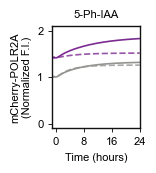

Saved Normal vs ARMC5 comparison to /Users/z3532965/src/publications/2026_POLR2A_homeostasis/Modelling/abundance_homeostasis/plots/model_comparison_Normal_vs_ARMC5.pdf


In [66]:
# Create Normal vs ARMC5 comparison plot (RFP only, both models)

fig, ax = plt.subplots(1, 1, figsize=(1.6, 1.77))
ax.set_facecolor("white")
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 8

# Colors: Normal = gray, ARMC5 = purple
color_normal = "#939591"
color_armc5 = "#7c2c91"

# Negative lead time
neg_times = np.linspace(-NEGATIVE_LEAD, 0, 20)

# Normal condition - Competition model
comp_traj_normal = comp_trajectories["VEH_AUX"]
A_comp_normal_0 = comp_traj_normal["A_n"][0]
A_neg_comp_normal = np.full_like(neg_times, A_comp_normal_0)
time_comp_normal = np.concatenate([neg_times, comp_traj_normal["time"]])
A_comp_normal = np.concatenate([A_neg_comp_normal, comp_traj_normal["A_n"]]) / RFP_NORM

ax.plot(
    time_comp_normal,
    A_comp_normal,
    color=color_normal,
    linewidth=1.2,
    linestyle="-",
    label="Normal (competition)",
)

# Normal condition - Feedback model
fb_traj_normal = fb_trajectories["VEH_AUX"]
A_fb_normal_0 = fb_traj_normal["A_n"][0]
A_neg_fb_normal = np.full_like(neg_times, A_fb_normal_0)
time_fb_normal = np.concatenate([neg_times, fb_traj_normal["time"]])
A_fb_normal = np.concatenate([A_neg_fb_normal, fb_traj_normal["A_n"]]) / RFP_NORM

ax.plot(
    time_fb_normal,
    A_fb_normal,
    color=color_normal,
    linewidth=1.2,
    linestyle="--",
    alpha=0.8,
    label="Normal (feedback)",
)

# ARMC5 condition - Competition model
comp_traj_armc5 = comp_trajectories_armc5["VEH_AUX"]
A_comp_armc5_0 = comp_traj_armc5["A_n"][0]
A_neg_comp_armc5 = np.full_like(neg_times, A_comp_armc5_0)
time_comp_armc5 = np.concatenate([neg_times, comp_traj_armc5["time"]])
A_comp_armc5 = np.concatenate([A_neg_comp_armc5, comp_traj_armc5["A_n"]]) / RFP_NORM

ax.plot(
    time_comp_armc5,
    A_comp_armc5,
    color=color_armc5,
    linewidth=1.2,
    linestyle="-",
    label="ARMC5 (competition)",
)

# ARMC5 condition - Feedback model
fb_traj_armc5 = fb_trajectories_armc5["VEH_AUX"]
A_fb_armc5_0 = fb_traj_armc5["A_n"][0]
A_neg_fb_armc5 = np.full_like(neg_times, A_fb_armc5_0)
time_fb_armc5 = np.concatenate([neg_times, fb_traj_armc5["time"]])
A_fb_armc5 = np.concatenate([A_neg_fb_armc5, fb_traj_armc5["A_n"]]) / RFP_NORM

ax.plot(
    time_fb_armc5,
    A_fb_armc5,
    color=color_armc5,
    linewidth=1.2,
    linestyle="--",
    alpha=0.8,
    label="ARMC5 (feedback)",
)

# Formatting
ax.set_xlim(-1, 24)
ax.set_ylim(-0.1, 2.1)
ax.set_xticks([0, 8, 16, 24])
ax.set_yticks([0.0, 1.0, 2.0])
ax.tick_params(
    axis="both", which="both", direction="out", length=3.0, width=0.6, labelsize=8
)
ax.set_title("5-Ph-IAA", fontsize=8)
ax.set_xlabel("Time (hours)", fontsize=8)
ax.set_ylabel("mCherry-POLR2A\n(Normalized F.I.)", fontsize=8)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_color("#111111")

ax.set_xticklabels(["0", "8", "16", "24"])

fig.tight_layout()

# Save to publication path
output_armc5_path = Path("plots/model_comparison_Normal_vs_ARMC5.pdf")
fig.savefig(output_armc5_path, bbox_inches="tight")
plt.show()

print(f"Saved Normal vs ARMC5 comparison to {output_armc5_path.resolve()}")